<a href="https://colab.research.google.com/github/sungfeliks/Lightweight-Mixture-of-Experts-with-Knowledge-Distillation-Vision-Language-Model/blob/main/03_student_mobilenetv3_small_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Environment and Configuration**

## **Installing dependencies**

In [1]:
!pip -q install \
    albumentations==1.4.7 \
    scikit-learn \
    opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 10.1 MB/s eta 0:00:00


## **Import, seed and runtime**

In [2]:
import gc
import json
import os
import random
import shutil
import time
import zipfile

from pathlib import Path

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision

from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm


SEED = 42


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"

print("PyTorch version    :", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Device             :", DEVICE)
print("AMP enabled        :", USE_AMP)

if torch.cuda.is_available():
    print(
        "GPU                :",
        torch.cuda.get_device_name(0),
    )

PyTorch version    : 2.11.0+cu128
Torchvision version: 0.26.0+cu128
Device             : cuda
AMP enabled        : True
GPU                : Tesla T4


## **Mount Google Drive**

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## **Path configuration**

In [4]:
DRIVE_PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Research"
)

CSV_DIR = (
    DRIVE_PROJECT_ROOT
    / "processed"
)

DATASET_DIR = (
    DRIVE_PROJECT_ROOT
    / "datasets"
)

DATASET_ZIP_PATH = (
    DATASET_DIR
    / "cbis_ddsm_awsaf.zip"
)

TRAIN_CSV_PATH = (
    CSV_DIR
    / "cbis_train.csv"
)

VAL_CSV_PATH = (
    CSV_DIR
    / "cbis_val.csv"
)

ALL_CSV_PATH = (
    CSV_DIR
    / "cbis_all.csv"
)

LOCAL_DATA_PARENT = Path("/content")

CBIS_ROOT = (
    LOCAL_DATA_PARENT
    / "cbis_ddsm_awsaf"
)

JPEG_DIR = (
    CBIS_ROOT
    / "jpeg"
)

OUTPUT_DIR = (
    DRIVE_PROJECT_ROOT
    / "outputs"
    / "student_mobilenetv3_small_baseline"
)

CHECKPOINT_DIR = (
    OUTPUT_DIR
    / "checkpoints"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BEST_STUDENT_PATH = (
    CHECKPOINT_DIR
    / "mobilenetv3_small_baseline_best.pt"
)

LAST_STUDENT_PATH = (
    CHECKPOINT_DIR
    / "mobilenetv3_small_baseline_last.pt"
)

STUDENT_HISTORY_PATH = (
    OUTPUT_DIR
    / "mobilenetv3_small_baseline_history.csv"
)

print("Train CSV     :", TRAIN_CSV_PATH)
print("Validation CSV:", VAL_CSV_PATH)
print("Dataset ZIP   :", DATASET_ZIP_PATH)
print("Local dataset :", CBIS_ROOT)
print("Output        :", OUTPUT_DIR)

Train CSV     : /content/drive/MyDrive/Research/processed/cbis_train.csv
Validation CSV: /content/drive/MyDrive/Research/processed/cbis_val.csv
Dataset ZIP   : /content/drive/MyDrive/Research/datasets/cbis_ddsm_awsaf.zip
Local dataset : /content/cbis_ddsm_awsaf
Output        : /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline


## **Extracting the dataset to the local runtime**

In [5]:
if not TRAIN_CSV_PATH.exists():
    raise FileNotFoundError(
        f"Train CSV not found: {TRAIN_CSV_PATH}"
    )

if not VAL_CSV_PATH.exists():
    raise FileNotFoundError(
        f"Validation CSV not found: {VAL_CSV_PATH}"
    )

if not JPEG_DIR.exists():
    if not DATASET_ZIP_PATH.exists():
        raise FileNotFoundError(
            f"ZIP dataset not found: "
            f"{DATASET_ZIP_PATH}"
        )

    print("Extracting dataset to /content...")

    with zipfile.ZipFile(
        DATASET_ZIP_PATH,
        "r",
    ) as zip_file:
        zip_file.extractall(
            CBIS_ROOT
        )

    print("Dataset extraction completed.")
else:
    print("Dataset is already available locally.")

Extracting dataset to /content...
Dataset extraction completed.


# **Student Dataset**

## **Upload CSV and verify the split**

In [6]:
train_df = pd.read_csv(
    TRAIN_CSV_PATH
)

val_df = pd.read_csv(
    VAL_CSV_PATH
)

print("Train shape     :", train_df.shape)
print("Validation shape:", val_df.shape)

print("\nTrain columns:")
print(train_df.columns.tolist())

print("\nTrain label distribution:")
print(
    train_df["cancer"]
    .value_counts()
    .sort_index()
)

print("\nValidation label distribution:")
print(
    val_df["cancer"]
    .value_counts()
    .sort_index()
)

Train shape     : (2482, 5)
Validation shape: (621, 5)

Train columns:
['image_path', 'patient_id', 'left or right breast', 'image view', 'cancer']

Train label distribution:
cancer
0    1394
1    1088
Name: count, dtype: int64

Validation label distribution:
cancer
0    334
1    287
Name: count, dtype: int64


**Set the ‘patient’ column automatically**

In [7]:
patient_column_candidates = [
    "patient_id",
    "patient",
    "PatientID",
    "patientID",
]

PATIENT_COLUMN = next(
    (
        column
        for column
        in patient_column_candidates
        if column in train_df.columns
    ),
    None,
)

if PATIENT_COLUMN is None:
    raise KeyError(
        "Kolom patient tidak ditemukan."
    )

required_columns = {
    "image_path",
    "cancer",
    PATIENT_COLUMN,
}

missing_train_columns = (
    required_columns
    - set(train_df.columns)
)

missing_val_columns = (
    required_columns
    - set(val_df.columns)
)

if missing_train_columns:
    raise KeyError(
        f"Missing train columns: "
        f"{missing_train_columns}"
    )

if missing_val_columns:
    raise KeyError(
        f"Missing validation columns: "
        f"{missing_val_columns}"
    )

train_patients = set(
    train_df[PATIENT_COLUMN].astype(str)
)

val_patients = set(
    val_df[PATIENT_COLUMN].astype(str)
)

patient_overlap = (
    train_patients & val_patients
)

print("Patient column :", PATIENT_COLUMN)
print("Train patients :", len(train_patients))
print("Val patients   :", len(val_patients))
print("Patient overlap:", len(patient_overlap))

assert len(patient_overlap) == 0

print(
    "Patient-level split verification successful."
)

Patient column : patient_id
Train patients : 1252
Val patients   : 314
Patient overlap: 0
Patient-level split verification successful.


## **Resolve image path**

In [8]:
def resolve_image_path(raw_path):
    raw_path = str(raw_path)

    direct_path = Path(raw_path)

    if direct_path.exists():
        return direct_path

    normalized_path = raw_path.replace(
        "\\",
        "/",
    )

    path_parts = [
        part
        for part in normalized_path.split("/")
        if part
    ]

    if "jpeg" in path_parts:
        jpeg_index = path_parts.index("jpeg")

        candidate = (
            CBIS_ROOT
            / Path(
                *path_parts[jpeg_index:]
            )
        )

        if candidate.exists():
            return candidate

    if "cbis_ddsm_awsaf" in path_parts:
        root_index = path_parts.index(
            "cbis_ddsm_awsaf"
        )

        candidate = (
            LOCAL_DATA_PARENT
            / Path(
                *path_parts[root_index:]
            )
        )

        if candidate.exists():
            return candidate

    candidate = (
        JPEG_DIR
        / Path(normalized_path).name
    )

    return candidate

**Verify the entire path**

In [9]:
train_resolved_paths = (
    train_df["image_path"]
    .map(resolve_image_path)
)

val_resolved_paths = (
    val_df["image_path"]
    .map(resolve_image_path)
)

missing_train_paths = [
    path
    for path in train_resolved_paths
    if not path.exists()
]

missing_val_paths = [
    path
    for path in val_resolved_paths
    if not path.exists()
]

print(
    "Missing train images:",
    len(missing_train_paths),
)
print(
    "Missing validation images:",
    len(missing_val_paths),
)

assert len(missing_train_paths) == 0
assert len(missing_val_paths) == 0

print("All image paths were resolved.")

Missing train images: 0
Missing validation images: 0
All image paths were resolved.


## **Student image configuration**

In [10]:
STUDENT_IMAGE_HEIGHT = 512
STUDENT_IMAGE_WIDTH = 320

IMAGENET_MEAN = np.asarray(
    [0.485, 0.456, 0.406],
    dtype=np.float32,
).reshape(1, 1, 3)

IMAGENET_STD = np.asarray(
    [0.229, 0.224, 0.225],
    dtype=np.float32,
).reshape(1, 1, 3)

print(
    "Student input size:",
    (
        STUDENT_IMAGE_HEIGHT,
        STUDENT_IMAGE_WIDTH,
    ),
)

Student input size: (512, 320)


## **Transform Student**

In [11]:
student_train_transform = A.Compose([
    A.Resize(
        height=STUDENT_IMAGE_HEIGHT,
        width=STUDENT_IMAGE_WIDTH,
    ),

    A.Affine(
        scale=(0.97, 1.03),
        translate_percent=(-0.02, 0.02),
        rotate=(-5, 5),
        shear=(-2, 2),
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        p=0.4,
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.08,
        contrast_limit=0.08,
        p=0.3,
    ),
])


student_val_transform = A.Compose([
    A.Resize(
        height=STUDENT_IMAGE_HEIGHT,
        width=STUDENT_IMAGE_WIDTH,
    ),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:34: UserWarning: Argument 'border_mode' is not valid and will be ignored.
  warn(
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:34: UserWarning: Argument 'value' is not valid and will be ignored.
  warn(


## **Dataset class**

In [12]:
class CBISStudentDataset(Dataset):
    def __init__(
        self,
        dataframe,
        transform,
        patient_column,
    ):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform
        self.patient_column = patient_column

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = resolve_image_path(
            row["image_path"]
        )

        if not image_path.exists():
            raise FileNotFoundError(
                f"Image not found: {image_path}"
            )

        image = Image.open(
            image_path
        ).convert("RGB")

        image = np.asarray(image)

        transformed = self.transform(
            image=image
        )

        image = transformed["image"].astype(
            np.float32
        )

        image_min = image.min()
        image_max = image.max()

        image = (
            image - image_min
        ) / (
            image_max
            - image_min
            + 1e-8
        )

        image = (
            image - IMAGENET_MEAN
        ) / IMAGENET_STD

        image = np.transpose(
            image,
            (2, 0, 1),
        )

        image = torch.from_numpy(
            np.ascontiguousarray(image)
        ).float()

        label = torch.tensor(
            float(row["cancer"]),
            dtype=torch.float32,
        )

        return {
            "images": image,
            "labels": label,
            "path": str(image_path),
            "patient": str(
                row[self.patient_column]
            ),
        }

## **Dataset and DataLoader**

In [13]:
STUDENT_BATCH_SIZE = 16
NUM_WORKERS = 2


student_train_dataset = CBISStudentDataset(
    dataframe=train_df,
    transform=student_train_transform,
    patient_column=PATIENT_COLUMN,
)

student_val_dataset = CBISStudentDataset(
    dataframe=val_df,
    transform=student_val_transform,
    patient_column=PATIENT_COLUMN,
)


student_train_loader = DataLoader(
    student_train_dataset,
    batch_size=STUDENT_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP,
    persistent_workers=(
        NUM_WORKERS > 0
    ),
    drop_last=False,
)


student_val_loader = DataLoader(
    student_val_dataset,
    batch_size=STUDENT_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP,
    persistent_workers=(
        NUM_WORKERS > 0
    ),
    drop_last=False,
)


print(
    "Train samples     :",
    len(student_train_dataset),
)
print(
    "Validation samples:",
    len(student_val_dataset),
)
print(
    "Train batches     :",
    len(student_train_loader),
)
print(
    "Validation batches:",
    len(student_val_loader),
)

Train samples     : 2482
Validation samples: 621
Train batches     : 156
Validation batches: 39


## **Batch sanity check**

In [14]:
student_batch = next(
    iter(student_train_loader)
)

student_images = student_batch[
    "images"
]

student_labels = student_batch[
    "labels"
]

print(
    "Images:",
    student_images.shape,
    student_images.dtype,
)

print(
    "Labels:",
    student_labels.shape,
    student_labels.dtype,
)

print(
    "Image minimum:",
    student_images.min().item(),
)

print(
    "Image maximum:",
    student_images.max().item(),
)

print(
    "All finite:",
    torch.isfinite(
        student_images
    ).all().item(),
)

print(
    "Labels:",
    student_labels.numpy(),
)

assert student_images.shape[1:] == (
    3,
    STUDENT_IMAGE_HEIGHT,
    STUDENT_IMAGE_WIDTH,
)

assert torch.isfinite(
    student_images
).all()

assert set(
    student_labels.numpy().tolist()
).issubset({0.0, 1.0})

Images: torch.Size([16, 3, 512, 320]) torch.float32
Labels: torch.Size([16]) torch.float32
Image minimum: -2.1179039478302
Image maximum: 2.640000104904175
All finite: True
Labels: [1. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 1. 0.]


## **Visualisation of student images**

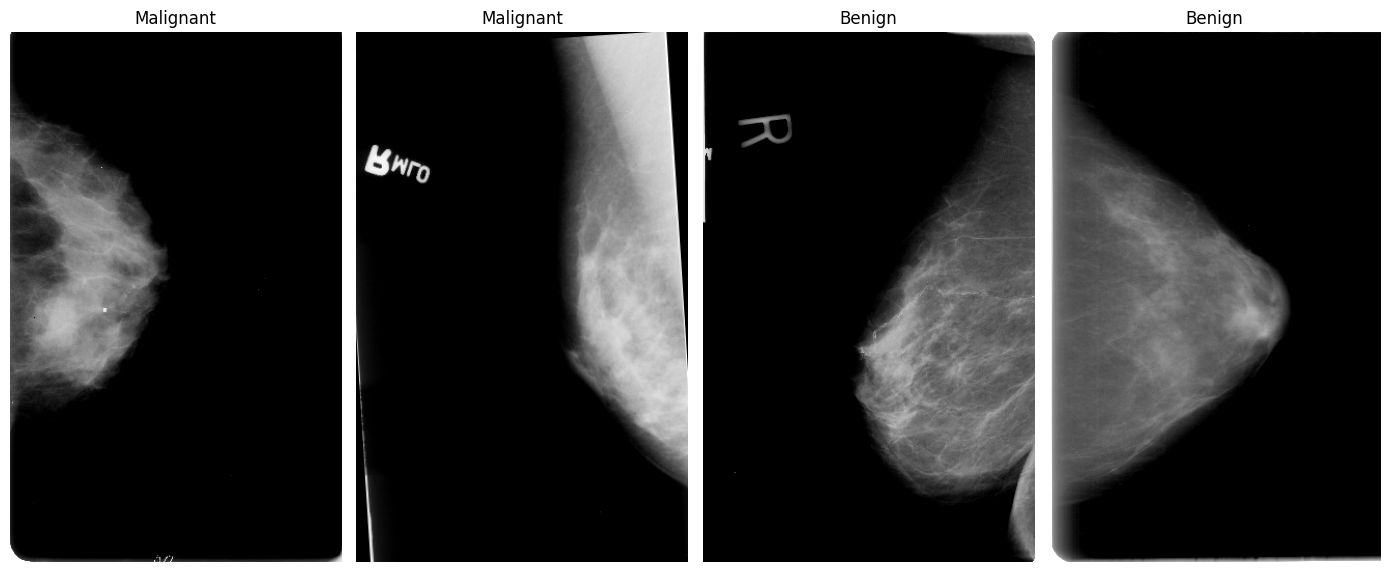

In [15]:
def denormalize_student_image(
    image_tensor,
):
    image = (
        image_tensor
        .detach()
        .cpu()
        .numpy()
    )

    image = np.transpose(
        image,
        (1, 2, 0),
    )

    image = (
        image * IMAGENET_STD
        + IMAGENET_MEAN
    )

    image = np.clip(
        image,
        0,
        1,
    )

    return image


figure, axes = plt.subplots(
    1,
    4,
    figsize=(14, 6),
)

for index, axis in enumerate(axes):
    image = denormalize_student_image(
        student_images[index]
    )

    label = int(
        student_labels[index].item()
    )

    axis.imshow(
        image,
        cmap="gray",
    )

    axis.set_title(
        "Malignant"
        if label == 1
        else "Benign"
    )

    axis.axis("off")

plt.tight_layout()
plt.show()

# **MobileNetV3-Small Baseline**

## **Import pretrained MobileNetV3-Small**

In [16]:
from torchvision.models import (
    MobileNet_V3_Small_Weights,
    mobilenet_v3_small,
)

## **Student Model Definition**

In [17]:
# To ensure a fair comparison with MoE, the standard ImageNet classifier was not used.
# The backbone produces pooled features of dimension 576, which are fed into a single linear
# classification head.

# In the forthcoming MoE experiment, this linear head will be replaced by three expert heads.

class MobileNetV3SmallStudent(nn.Module):
    def __init__(
        self,
        pretrained=True,
        dropout=0.2,
    ):
        super().__init__()

        weights = (
            MobileNet_V3_Small_Weights
            .IMAGENET1K_V1
            if pretrained
            else None
        )

        backbone = mobilenet_v3_small(
            weights=weights
        )

        self.features = backbone.features
        self.avgpool = nn.AdaptiveAvgPool2d(
            output_size=1
        )

        self.feature_dim = (
            backbone.classifier[0].in_features
        )

        self.dropout = nn.Dropout(
            p=dropout
        )

        self.classifier = nn.Linear(
            self.feature_dim,
            1,
        )

    def encode(self, images):
        raw_features = self.features(
            images
        )

        pooled_features = self.avgpool(
            raw_features
        )

        pooled_features = torch.flatten(
            pooled_features,
            start_dim=1,
        )

        return (
            pooled_features,
            raw_features,
        )

    def forward(
        self,
        images,
        return_features=False,
    ):
        (
            pooled_features,
            raw_features,
        ) = self.encode(images)

        dropped_features = self.dropout(
            pooled_features
        )

        logits = self.classifier(
            dropped_features
        )

        if return_features:
            return {
                "logits": logits,
                "pooled_features": (
                    pooled_features
                ),
                "raw_features": raw_features,
            }

        return logits

## **Build Model**

In [18]:
student = MobileNetV3SmallStudent(
    pretrained=True,
    dropout=0.2,
)

student = student.to(DEVICE)

print(student)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 199MB/s]

MobileNetV3SmallStudent(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_s

## **Summary of parameters**

In [19]:
student_total_parameters = sum(
    parameter.numel()
    for parameter in student.parameters()
)

student_trainable_parameters = sum(
    parameter.numel()
    for parameter in student.parameters()
    if parameter.requires_grad
)

student_backbone_parameters = sum(
    parameter.numel()
    for parameter in student.features.parameters()
)

student_classifier_parameters = sum(
    parameter.numel()
    for parameter in student.classifier.parameters()
)

print(
    "Feature dimension     :",
    student.feature_dim,
)

print(
    "Total parameters      :",
    f"{student_total_parameters:,}",
)

print(
    "Trainable parameters  :",
    f"{student_trainable_parameters:,}",
)

print(
    "Backbone parameters   :",
    f"{student_backbone_parameters:,}",
)

print(
    "Classifier parameters :",
    f"{student_classifier_parameters:,}",
)

assert student.feature_dim == 576
assert student_classifier_parameters == 577
assert (
    student_total_parameters
    == student_trainable_parameters
)

print(
    "MobileNetV3-Small baseline "
    "configuration verified."
)

Feature dimension     : 576
Total parameters      : 927,585
Trainable parameters  : 927,585
Backbone parameters   : 927,008
Classifier parameters : 577
MobileNetV3-Small baseline configuration verified.


# **Forward and Backward Sanity Checks**

## **Forward pass**

In [20]:
student.train()

sanity_images = (
    student_images[:4]
    .to(
        DEVICE,
        non_blocking=True,
    )
)

sanity_labels = (
    student_labels[:4]
    .to(
        DEVICE,
        non_blocking=True,
    )
    .float()
    .view(-1)
)

with torch.autocast(
    device_type=DEVICE.type,
    dtype=torch.float16,
    enabled=USE_AMP,
):
    student_output = student(
        sanity_images,
        return_features=True,
    )

student_logits = student_output[
    "logits"
]

student_pooled_features = (
    student_output[
        "pooled_features"
    ]
)

student_raw_features = student_output[
    "raw_features"
]

print(
    "Images          :",
    sanity_images.shape,
)

print(
    "Labels          :",
    sanity_labels.shape,
)

print(
    "Logits          :",
    student_logits.shape,
)

print(
    "Pooled features :",
    student_pooled_features.shape,
)

print(
    "Raw features    :",
    student_raw_features.shape,
)

Images          : torch.Size([4, 3, 512, 320])
Labels          : torch.Size([4])
Logits          : torch.Size([4, 1])
Pooled features : torch.Size([4, 576])
Raw features    : torch.Size([4, 576, 16, 10])


## **Initial probability**

In [21]:
student_probabilities = torch.sigmoid(
    student_logits.view(-1)
)

print(
    "Labels:",
    sanity_labels
    .detach()
    .cpu()
    .numpy(),
)

print(
    "Logits:",
    student_logits
    .view(-1)
    .detach()
    .float()
    .cpu()
    .numpy()
    .round(4),
)

print(
    "Probabilities:",
    student_probabilities
    .detach()
    .float()
    .cpu()
    .numpy(),
)

assert torch.isfinite(
    student_logits
).all()

assert student_probabilities.min() >= 0
assert student_probabilities.max() <= 1

Labels: [1. 1. 0. 0.]
Logits: [-0.3726  0.1161 -0.4683 -0.3872]
Probabilities: [0.40795898 0.5288086  0.38500977 0.40429688]


## **BCE loss**

In [22]:
student_criterion = (
    nn.BCEWithLogitsLoss()
)

student_loss = student_criterion(
    student_logits.view(-1),
    sanity_labels,
)

print(
    "Student sanity-check loss:",
    student_loss.item(),
)

assert torch.isfinite(
    student_loss
)

Student sanity-check loss: 0.6343994140625


## **Backward sanity check**

In [23]:
student.zero_grad(
    set_to_none=True
)

student_loss.backward()

backbone_has_gradient = any(
    parameter.grad is not None
    and torch.isfinite(
        parameter.grad
    ).all()
    for parameter
    in student.features.parameters()
)

classifier_has_gradient = any(
    parameter.grad is not None
    and torch.isfinite(
        parameter.grad
    ).all()
    for parameter
    in student.classifier.parameters()
)

classifier_gradient_norm = (
    student.classifier.weight.grad
    .detach()
    .norm()
    .item()
)

print(
    "Backbone gradient       :",
    backbone_has_gradient,
)

print(
    "Classifier gradient     :",
    classifier_has_gradient,
)

print(
    "Classifier gradient norm:",
    classifier_gradient_norm,
)

assert backbone_has_gradient is True
assert classifier_has_gradient is True
assert classifier_gradient_norm > 0

print(
    "MobileNetV3-Small forward and "
    "backward sanity checks succeeded."
)

Backbone gradient       : True
Classifier gradient     : True
Classifier gradient norm: 1.5024000406265259
MobileNetV3-Small forward and backward sanity checks succeeded.


## **Clear the temporary tensor**

In [24]:
student.zero_grad(
    set_to_none=True
)

temporary_variables = [
    "student_batch",
    "student_images",
    "student_labels",
    "sanity_images",
    "sanity_labels",
    "student_output",
    "student_logits",
    "student_probabilities",
    "student_pooled_features",
    "student_raw_features",
    "student_loss",
]

for variable_name in temporary_variables:
    globals().pop(
        variable_name,
        None,
    )

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

    print(
        "GPU allocated:",
        f"{torch.cuda.memory_allocated() / 1024**3:.3f} GB",
    )

    print(
        "GPU reserved :",
        f"{torch.cuda.memory_reserved() / 1024**3:.3f} GB",
    )

print("Student sanity tensors cleaned.")

GPU allocated: 0.019 GB
GPU reserved : 0.023 GB
Student sanity tensors cleaned.


# **Training MobileNetV3-Small Baseline**

## **Training Configuration**

In [25]:
STUDENT_EPOCHS = 12

STUDENT_BACKBONE_LR = 1e-4
STUDENT_CLASSIFIER_LR = 5e-4 # The learning rate for the classifier was set higher
                             # because the classification head is still new, whilst
                             # the backbone already has ImageNet weights.
STUDENT_WEIGHT_DECAY = 1e-4

STUDENT_EARLY_STOPPING_PATIENCE = 4
STUDENT_MIN_IMPROVEMENT = 1e-4
STUDENT_MAX_GRAD_NORM = 5.0

STUDENT_THRESHOLD = 0.5

print("MobileNetV3-Small baseline training")
print("-" * 45)
print("Maximum epochs          :", STUDENT_EPOCHS)
print("Backbone learning rate  :", STUDENT_BACKBONE_LR)
print("Classifier learning rate:", STUDENT_CLASSIFIER_LR)
print("Weight decay            :", STUDENT_WEIGHT_DECAY)
print(
    "Early stopping patience :",
    STUDENT_EARLY_STOPPING_PATIENCE,
)
print("Decision threshold      :", STUDENT_THRESHOLD)
print("AMP enabled             :", USE_AMP)
print("Best checkpoint         :", BEST_STUDENT_PATH)
print("Last checkpoint         :", LAST_STUDENT_PATH)

MobileNetV3-Small baseline training
---------------------------------------------
Maximum epochs          : 12
Backbone learning rate  : 0.0001
Classifier learning rate: 0.0005
Weight decay            : 0.0001
Early stopping patience : 4
Decision threshold      : 0.5
AMP enabled             : True
Best checkpoint         : /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/checkpoints/mobilenetv3_small_baseline_best.pt
Last checkpoint         : /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/checkpoints/mobilenetv3_small_baseline_last.pt


## **Binary classification metric functions**

In [26]:
def calculate_binary_metrics(
    labels,
    probabilities,
    threshold=0.5,
):
    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=np.float64,
    )

    predictions = (
        probabilities >= threshold
    ).astype(np.int64)

    accuracy = accuracy_score(
        labels,
        predictions,
    )

    balanced_accuracy = balanced_accuracy_score(
        labels,
        predictions,
    )

    precision = precision_score(
        labels,
        predictions,
        zero_division=0,
    )

    sensitivity = recall_score(
        labels,
        predictions,
        zero_division=0,
    )

    f1 = f1_score(
        labels,
        predictions,
        zero_division=0,
    )

    confusion = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    )

    tn, fp, fn, tp = confusion.ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    roc_auc = (
        roc_auc_score(
            labels,
            probabilities,
        )
        if np.unique(labels).size == 2
        else np.nan
    )

    return {
        "roc_auc": float(roc_auc),
        "accuracy": float(accuracy),
        "balanced_accuracy": float(
            balanced_accuracy
        ),
        "precision": float(precision),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "f1": float(f1),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

## **One-epoch training**

In [27]:
def train_student_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    scaler,
    device,
    threshold=0.5,
):
    model.train()

    running_loss = 0.0
    sample_count = 0

    all_labels = []
    all_probabilities = []

    progress_bar = tqdm(
        data_loader,
        desc="Student training",
        leave=False,
    )

    for batch in progress_bar:
        images = batch["images"].to(
            device,
            non_blocking=True,
        )

        labels = batch["labels"].to(
            device,
            non_blocking=True,
        ).float().view(-1)

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            logits = model(
                images
            ).view(-1)

            loss = criterion(
                logits,
                labels,
            )

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=STUDENT_MAX_GRAD_NORM,
        )

        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)

        running_loss += (
            loss.detach().item()
            * batch_size
        )

        sample_count += batch_size

        probabilities = torch.sigmoid(
            logits.detach()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = (
        running_loss / sample_count
    )

    metrics = calculate_binary_metrics(
        labels=all_labels,
        probabilities=all_probabilities,
        threshold=threshold,
    )

    metrics["loss"] = float(epoch_loss)

    return metrics

## **One-epoch validation**

In [28]:
@torch.inference_mode()
def validate_student_one_epoch(
    model,
    data_loader,
    criterion,
    device,
    threshold=0.5,
):
    model.eval()

    running_loss = 0.0
    sample_count = 0

    all_labels = []
    all_probabilities = []

    progress_bar = tqdm(
        data_loader,
        desc="Student validation",
        leave=False,
    )

    for batch in progress_bar:
        images = batch["images"].to(
            device,
            non_blocking=True,
        )

        labels = batch["labels"].to(
            device,
            non_blocking=True,
        ).float().view(-1)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            logits = model(
                images
            ).view(-1)

            loss = criterion(
                logits,
                labels,
            )

        batch_size = labels.size(0)

        running_loss += (
            loss.detach().item()
            * batch_size
        )

        sample_count += batch_size

        probabilities = torch.sigmoid(
            logits
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

    epoch_loss = (
        running_loss / sample_count
    )

    metrics = calculate_binary_metrics(
        labels=all_labels,
        probabilities=all_probabilities,
        threshold=threshold,
    )

    metrics["loss"] = float(epoch_loss)

    return metrics

## **Loss, optimiser, scheduler and AMP**

In [29]:
student_criterion = nn.BCEWithLogitsLoss()

student_optimizer = torch.optim.AdamW(
    [
        {
            "params": student.features.parameters(),
            "lr": STUDENT_BACKBONE_LR,
            "name": "backbone",
        },
        {
            "params": student.classifier.parameters(),
            "lr": STUDENT_CLASSIFIER_LR,
            "name": "classifier",
        },
    ],
    weight_decay=STUDENT_WEIGHT_DECAY,
)

student_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        student_optimizer,
        mode="max",
        factor=0.5,
        patience=1,
        min_lr=1e-7,
    )
)

try:
    student_scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )
except TypeError:
    student_scaler = (
        torch.cuda.amp.GradScaler(
            enabled=USE_AMP,
        )
    )

print("Criterion:", student_criterion)

for index, parameter_group in enumerate(
    student_optimizer.param_groups
):
    print(
        f"Group {index}: "
        f"{parameter_group['name']} | "
        f"LR = {parameter_group['lr']:.2e}"
    )

Criterion: BCEWithLogitsLoss()
Group 0: backbone | LR = 1.00e-04
Group 1: classifier | LR = 5.00e-04


## **Run the baseline training**

In [30]:
student_history = []

best_student_auc = -np.inf
best_student_epoch = 0
epochs_without_improvement = 0

student_training_start = time.time()

for epoch in range(
    1,
    STUDENT_EPOCHS + 1,
):
    epoch_start = time.time()

    current_backbone_lr = (
        student_optimizer
        .param_groups[0]["lr"]
    )

    current_classifier_lr = (
        student_optimizer
        .param_groups[1]["lr"]
    )

    train_metrics = train_student_one_epoch(
        model=student,
        data_loader=student_train_loader,
        criterion=student_criterion,
        optimizer=student_optimizer,
        scaler=student_scaler,
        device=DEVICE,
        threshold=STUDENT_THRESHOLD,
    )

    val_metrics = validate_student_one_epoch(
        model=student,
        data_loader=student_val_loader,
        criterion=student_criterion,
        device=DEVICE,
        threshold=STUDENT_THRESHOLD,
    )

    scheduler_metric = val_metrics["roc_auc"]

    if np.isnan(scheduler_metric):
        scheduler_metric = val_metrics[
            "balanced_accuracy"
        ]

    student_scheduler.step(
        scheduler_metric
    )

    epoch_seconds = (
        time.time() - epoch_start
    )

    epoch_record = {
        "epoch": epoch,
        "backbone_lr": current_backbone_lr,
        "classifier_lr": (
            current_classifier_lr
        ),
        "train_loss": train_metrics["loss"],
        "train_roc_auc": train_metrics[
            "roc_auc"
        ],
        "train_accuracy": train_metrics[
            "accuracy"
        ],
        "train_balanced_accuracy": (
            train_metrics[
                "balanced_accuracy"
            ]
        ),
        "train_f1": train_metrics["f1"],
        "train_sensitivity": train_metrics[
            "sensitivity"
        ],
        "train_specificity": train_metrics[
            "specificity"
        ],
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics[
            "roc_auc"
        ],
        "val_accuracy": val_metrics[
            "accuracy"
        ],
        "val_balanced_accuracy": (
            val_metrics[
                "balanced_accuracy"
            ]
        ),
        "val_f1": val_metrics["f1"],
        "val_sensitivity": val_metrics[
            "sensitivity"
        ],
        "val_specificity": val_metrics[
            "specificity"
        ],
        "epoch_seconds": epoch_seconds,
    }

    student_history.append(
        epoch_record
    )

    print(
        f"Epoch {epoch:02d}/"
        f"{STUDENT_EPOCHS:02d} | "
        f"Backbone LR "
        f"{current_backbone_lr:.2e} | "
        f"Head LR "
        f"{current_classifier_lr:.2e} | "
        f"Train Loss "
        f"{train_metrics['loss']:.4f} | "
        f"Train AUC "
        f"{train_metrics['roc_auc']:.4f} | "
        f"Val Loss "
        f"{val_metrics['loss']:.4f} | "
        f"Val AUC "
        f"{val_metrics['roc_auc']:.4f} | "
        f"Val Sens "
        f"{val_metrics['sensitivity']:.4f} | "
        f"Val Spec "
        f"{val_metrics['specificity']:.4f} | "
        f"{epoch_seconds / 60:.2f} min"
    )

    current_val_auc = val_metrics[
        "roc_auc"
    ]

    if np.isnan(current_val_auc):
        current_val_auc = val_metrics[
            "balanced_accuracy"
        ]

    improved = (
        current_val_auc
        > best_student_auc
        + STUDENT_MIN_IMPROVEMENT
    )

    if improved:
        best_student_auc = current_val_auc
        best_student_epoch = epoch
        epochs_without_improvement = 0

        best_student_checkpoint = {
            "epoch": epoch,
            "model_state_dict": (
                student.state_dict()
            ),
            "optimizer_state_dict": (
                student_optimizer.state_dict()
            ),
            "scheduler_state_dict": (
                student_scheduler.state_dict()
            ),
            "scaler_state_dict": (
                student_scaler.state_dict()
            ),
            "train_metrics": train_metrics,
            "val_metrics": val_metrics,
            "best_val_auc": (
                best_student_auc
            ),
            "feature_dim": (
                student.feature_dim
            ),
            "image_height": (
                STUDENT_IMAGE_HEIGHT
            ),
            "image_width": (
                STUDENT_IMAGE_WIDTH
            ),
            "threshold": (
                STUDENT_THRESHOLD
            ),
            "training_stage": (
                "mobilenetv3_small_baseline"
            ),
        }

        torch.save(
            best_student_checkpoint,
            BEST_STUDENT_PATH,
        )

        print(
            "  ✓ Best baseline checkpoint "
            f"saved (Val AUC: "
            f"{best_student_auc:.4f})"
        )

    else:
        epochs_without_improvement += 1

        print(
            "  No validation AUC improvement "
            f"for {epochs_without_improvement} "
            "epoch(s)."
        )

    student_history_df = pd.DataFrame(
        student_history
    )

    student_history_df.to_csv(
        STUDENT_HISTORY_PATH,
        index=False,
    )

    last_student_checkpoint = {
        "epoch": epoch,
        "model_state_dict": (
            student.state_dict()
        ),
        "optimizer_state_dict": (
            student_optimizer.state_dict()
        ),
        "scheduler_state_dict": (
            student_scheduler.state_dict()
        ),
        "scaler_state_dict": (
            student_scaler.state_dict()
        ),
        "best_val_auc": (
            best_student_auc
        ),
        "best_epoch": (
            best_student_epoch
        ),
        "epochs_without_improvement": (
            epochs_without_improvement
        ),
        "history": student_history,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
    }

    torch.save(
        last_student_checkpoint,
        LAST_STUDENT_PATH,
    )

    if (
        epochs_without_improvement
        >= STUDENT_EARLY_STOPPING_PATIENCE
    ):
        print(
            "\nEarly stopping activated at "
            f"epoch {epoch}."
        )
        break

student_training_seconds = (
    time.time() - student_training_start
)

print("\nStudent baseline training completed.")
print(
    "Best epoch   :",
    best_student_epoch,
)
print(
    "Best val AUC :",
    f"{best_student_auc:.4f}",
)
print(
    "Training time:",
    f"{student_training_seconds / 60:.2f} minutes",
)
print(
    "Best checkpoint:",
    BEST_STUDENT_PATH,
)
print(
    "Last checkpoint:",
    LAST_STUDENT_PATH,
)
print(
    "History CSV:",
    STUDENT_HISTORY_PATH,
)

Student training:   0%|          | 0/156 [00:00<?, ?it/s]

Student validation:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 01/12 | Backbone LR 1.00e-04 | Head LR 5.00e-04 | Train Loss 0.6526 | Train AUC 0.6467 | Val Loss 0.6660 | Val AUC 0.6194 | Val Sens 0.1882 | Val Spec 0.8563 | 9.55 min
  ✓ Best baseline checkpoint saved (Val AUC: 0.6194)


Student training:   0%|          | 0/156 [00:00<?, ?it/s]

Student validation:   0%|          | 0/39 [00:00<?, ?it/s]

...

Student validation:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 11/12 | Backbone LR 2.50e-05 | Head LR 1.25e-04 | Train Loss 0.3385 | Train AUC 0.9285 | Val Loss 0.7011 | Val AUC 0.7575 | Val Sens 0.6202 | Val Spec 0.7395 | 7.81 min
  No validation AUC improvement for 3 epoch(s).


Student training:   0%|          | 0/156 [00:00<?, ?it/s]

Student validation:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 12/12 | Backbone LR 2.50e-05 | Head LR 1.25e-04 | Train Loss 0.3289 | Train AUC 0.9317 | Val Loss 0.7344 | Val AUC 0.7468 | Val Sens 0.6829 | Val Spec 0.6557 | 7.92 min
  No validation AUC improvement for 4 epoch(s).

Early stopping activated at epoch 12.

Student baseline training completed.
Best epoch   : 8
Best val AUC : 0.7716
Training time: 96.84 minutes
Best checkpoint: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/checkpoints/mobilenetv3_small_baseline_best.pt
Last checkpoint: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/checkpoints/mobilenetv3_small_baseline_last.pt
History CSV: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/mobilenetv3_small_baseline_history.csv


## **Resume Checkpoint (In the event that the runtime is terminated)**

In [ ]:
RESUME_STUDENT_TRAINING = True

start_epoch = 1
student_history = []

best_student_auc = -np.inf
best_student_epoch = 0
epochs_without_improvement = 0

if (
    RESUME_STUDENT_TRAINING
    and LAST_STUDENT_PATH.exists()
):
    print(
        "Loading last student checkpoint:",
        LAST_STUDENT_PATH,
    )

    resume_checkpoint = torch.load(
        LAST_STUDENT_PATH,
        map_location=DEVICE,
        weights_only=False,
    )

    student.load_state_dict(
        resume_checkpoint["model_state_dict"],
        strict=True,
    )

    student_optimizer.load_state_dict(
        resume_checkpoint[
            "optimizer_state_dict"
        ]
    )

    student_scheduler.load_state_dict(
        resume_checkpoint[
            "scheduler_state_dict"
        ]
    )

    if (
        "scaler_state_dict"
        in resume_checkpoint
    ):
        student_scaler.load_state_dict(
            resume_checkpoint[
                "scaler_state_dict"
            ]
        )

    completed_epoch = int(
        resume_checkpoint["epoch"]
    )

    start_epoch = completed_epoch + 1

    best_student_auc = float(
        resume_checkpoint["best_val_auc"]
    )

    best_student_epoch = int(
        resume_checkpoint["best_epoch"]
    )

    epochs_without_improvement = int(
        resume_checkpoint.get(
            "epochs_without_improvement",
            0,
        )
    )

    student_history = (
        resume_checkpoint.get(
            "history",
            [],
        )
    )

    student = student.to(DEVICE)

    print("\nStudent training resumed.")
    print(
        "Last completed epoch:",
        completed_epoch,
    )
    print(
        "Continue from epoch :",
        start_epoch,
    )
    print(
        "Best epoch so far   :",
        best_student_epoch,
    )
    print(
        "Best validation AUC :",
        f"{best_student_auc:.4f}",
    )
    print(
        "No-improvement count:",
        epochs_without_improvement,
    )

elif RESUME_STUDENT_TRAINING:
    print(
        "No last checkpoint was found. "
        "Training will start from epoch 1."
    )

else:
    print(
        "Resume disabled. Training will "
        "start from epoch 1."
    )

## **Load the best checkpoint**

In [31]:
best_student_checkpoint = torch.load(
    BEST_STUDENT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

student.load_state_dict(
    best_student_checkpoint[
        "model_state_dict"
    ],
    strict=True,
)

student = student.to(DEVICE)
student.eval()

print(
    "Loaded best student epoch:",
    best_student_checkpoint["epoch"],
)

print(
    "Loaded best validation AUC:",
    best_student_checkpoint[
        "best_val_auc"
    ],
)

print(
    "Validation metrics:",
    best_student_checkpoint[
        "val_metrics"
    ],
)

Loaded best student epoch: 8
Loaded best validation AUC: 0.7716466022658517
Validation metrics: {'roc_auc': 0.7716466022658517, 'accuracy': 0.6988727858293076, 'balanced_accuracy': 0.6945638340044649, 'precision': 0.6879699248120301, 'sensitivity': 0.6376306620209059, 'specificity': 0.7514970059880239, 'f1': 0.6618444846292948, 'tn': 251, 'fp': 83, 'fn': 104, 'tp': 183, 'loss': 0.592517955771583}


## **Display training history**

In [32]:
student_history_df = pd.read_csv(
    STUDENT_HISTORY_PATH
)

display(
    student_history_df.round(4)
)

,epoch,backbone_lr,classifier_lr,train_loss,train_roc_auc,train_accuracy,train_balanced_accuracy,train_f1,train_sensitivity,train_specificity,val_loss,val_roc_auc,val_accuracy,val_balanced_accuracy,val_f1,val_sensitivity,val_specificity,epoch_seconds
0,1,0.0001,0.0005,0.6526,0.6467,0.6060,0.5751,0.4192,0.3244,0.8257,0.6660,0.6194,0.5475,0.5222,0.2776,0.1882,0.8563,572.8100
1,2,0.0001,0.0005,0.5930,0.7335,0.6604,0.6518,0.6007,0.5827,0.7209,0.6284,0.6694,0.6039,0.6055,0.5941,0.6272,0.5838,473.1231
2,3,0.0001,0.0005,0.5630,0.7706,0.6930,0.6861,0.6429,0.6305,0.7418,0.6158,0.7053,0.6361,0.6308,0.5876,0.5610,0.7006,478.9667
3,4,0.0001,0.0005,0.5190,0.8119,0.7264,0.7225,0.6887,0.6903,0.7547,0.5898,0.7358,0.6538,0.6556,0.6446,0.6794,0.6317,471.8049
4,5,0.0001,0.0005,0.4952,0.8325,0.7466,0.7427,0.7111,0.7114,0.7740,0.6222,0.7418,0.6425,0.6571,0.6873,0.8502,0.4641,472.2108
5,6,0.0001,0.0005,0.4694,0.8516,0.7615,0.7573,0.7267,0.7233,0.7912,0.7639,0.7280,0.6345,0.6146,0.4709,0.3519,0.8772,482.4595
6,7,0.0001,0.0005,0.4487,0.8686,0.7897,0.7861,0.7594,0.7574,0.8149,0.6429,0.7288,0.6634,0.6668,0.6613,0.7108,0.6228,475.2656
7,8,0.0000,0.0002,0.3949,0.9006,0.8143,0.8103,0.7861,0.7785,0.8422,0.5925,0.7716,0.6989,0.6946,0.6618,0.6376,0.7515,477.5702
8,9,0.0000,0.0002,0.3613,0.9173,0.8388,0.8368,0.8168,0.8199,0.8537,0.6590,0.7597,0.6763,0.6704,0.6285,0.5923,0.7485,483.9064
9,10,0.0000,0.0002,0.3603,0.9179,0.8272,0.8243,0.8026,0.8015,0.8472,0.7227,0.7438,0.6634,0.6550,0.5988,0.5436,0.7665,475.9284


# **MobileNetV3-Small Baseline Evaluation**

## **Collect validation predictions**

In [33]:
@torch.inference_mode()
def collect_student_predictions(
    model,
    data_loader,
    device,
):
    model.eval()

    all_labels = []
    all_logits = []
    all_probabilities = []
    all_paths = []
    all_patients = []

    progress_bar = tqdm(
        data_loader,
        desc="Collecting student predictions",
        leave=False,
    )

    for batch in progress_bar:
        images = batch["images"].to(
            device,
            non_blocking=True,
        )

        labels = (
            batch["labels"]
            .float()
            .view(-1)
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            logits = model(images).view(-1)

        probabilities = torch.sigmoid(logits)

        batch_size = labels.size(0)

        all_labels.extend(
            labels.cpu().numpy().tolist()
        )

        all_logits.extend(
            logits.float().cpu().numpy().tolist()
        )

        all_probabilities.extend(
            probabilities.float().cpu().numpy().tolist()
        )

        all_paths.extend(
            list(batch.get(
                "path",
                [None] * batch_size,
            ))
        )

        all_patients.extend(
            list(batch.get(
                "patient",
                [None] * batch_size,
            ))
        )

    return pd.DataFrame({
        "image_path": all_paths,
        "patient_id": all_patients,
        "label": np.asarray(
            all_labels,
            dtype=np.int64,
        ),
        "logit": np.asarray(
            all_logits,
            dtype=np.float32,
        ),
        "probability": np.asarray(
            all_probabilities,
            dtype=np.float32,
        ),
    })


student_val_prediction_df = (
    collect_student_predictions(
        model=student,
        data_loader=student_val_loader,
        device=DEVICE,
    )
)

print(
    "Validation predictions:",
    len(student_val_prediction_df),
)

display(
    student_val_prediction_df[
        ["label", "probability"]
    ].head()
)

assert len(student_val_prediction_df) == 621
assert (
    student_val_prediction_df["label"]
    .nunique()
    == 2
)
assert (
    student_val_prediction_df["probability"]
    .between(0, 1)
    .all()
)

Validation predictions: 621


,label,probability
0,0,0.157349
1,0,0.496338
2,0,0.787109
3,1,0.419434
4,0,0.454590


## **ROC-AUC, PR-AUC, dan Average Precision**

In [34]:
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)


student_val_labels = (
    student_val_prediction_df["label"]
    .to_numpy()
    .astype(np.int64)
)

student_val_probabilities = (
    student_val_prediction_df["probability"]
    .to_numpy()
    .astype(np.float64)
)

student_fpr, student_tpr, student_roc_thresholds = (
    roc_curve(
        student_val_labels,
        student_val_probabilities,
    )
)

student_roc_auc = auc(
    student_fpr,
    student_tpr,
)

(
    student_precision_curve,
    student_recall_curve,
    student_pr_thresholds,
) = precision_recall_curve(
    student_val_labels,
    student_val_probabilities,
)

student_pr_auc = auc(
    student_recall_curve,
    student_precision_curve,
)

student_average_precision = (
    average_precision_score(
        student_val_labels,
        student_val_probabilities,
    )
)

print(
    "Student validation ROC-AUC:",
    f"{student_roc_auc:.4f}",
)

print(
    "Student validation PR-AUC :",
    f"{student_pr_auc:.4f}",
)

print(
    "Student Average Precision :",
    f"{student_average_precision:.4f}",
)

Student validation ROC-AUC: 0.7716
Student validation PR-AUC : 0.7420
Student Average Precision : 0.7435


## **Threshold Youden student**

In [35]:
student_youden_j = (
    student_tpr - student_fpr
)

student_best_threshold_index = np.argmax(
    student_youden_j
)

student_optimal_threshold = float(
    student_roc_thresholds[
        student_best_threshold_index
    ]
)

student_optimal_sensitivity = float(
    student_tpr[
        student_best_threshold_index
    ]
)

student_optimal_specificity = float(
    1.0
    - student_fpr[
        student_best_threshold_index
    ]
)

print(
    "Student optimal threshold:",
    f"{student_optimal_threshold:.4f}",
)

print(
    "Sensitivity:",
    f"{student_optimal_sensitivity:.4f}",
)

print(
    "Specificity:",
    f"{student_optimal_specificity:.4f}",
)

print(
    "Youden's J:",
    f"{student_youden_j[student_best_threshold_index]:.4f}",
)

Student optimal threshold: 0.5166
Sensitivity: 0.6272
Specificity: 0.7665
Youden's J: 0.3936


## **Compare thresholds**

In [36]:
student_metrics_threshold_05 = (
    calculate_binary_metrics(
        labels=student_val_labels,
        probabilities=student_val_probabilities,
        threshold=0.5,
    )
)

student_metrics_optimal = (
    calculate_binary_metrics(
        labels=student_val_labels,
        probabilities=student_val_probabilities,
        threshold=student_optimal_threshold,
    )
)

student_threshold_comparison_df = pd.DataFrame([
    {
        "threshold_type": "Default 0.5",
        "threshold": 0.5,
        **student_metrics_threshold_05,
    },
    {
        "threshold_type": "Youden optimal",
        "threshold": student_optimal_threshold,
        **student_metrics_optimal,
    },
])

display(
    student_threshold_comparison_df.round(4)
)

,threshold_type,threshold,roc_auc,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,tn,fp,fn,tp
0,Default 0.5,0.5000,0.7716,0.6989,0.6946,0.6880,0.6376,0.7515,0.6618,251,83,104,183
1,Youden optimal,0.5166,0.7716,0.7021,0.6968,0.6977,0.6272,0.7665,0.6606,256,78,107,180


## **Confusion Matrix**

              precision    recall  f1-score   support

      Benign     0.7052    0.7665    0.7346       334
   Malignant     0.6977    0.6272    0.6606       287

    accuracy                         0.7021       621
   macro avg     0.7015    0.6968    0.6976       621
weighted avg     0.7017    0.7021    0.7004       621



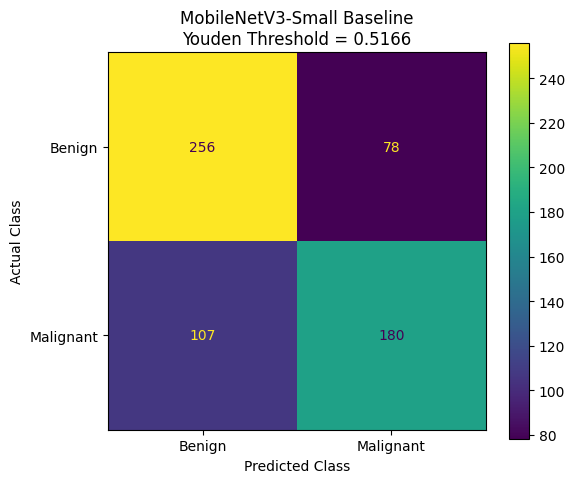

In [37]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
)


student_optimal_predictions = (
    student_val_probabilities
    >= student_optimal_threshold
).astype(np.int64)

print(
    classification_report(
        student_val_labels,
        student_optimal_predictions,
        target_names=[
            "Benign",
            "Malignant",
        ],
        digits=4,
        zero_division=0,
    )
)

STUDENT_CONFUSION_MATRIX_PATH = (
    OUTPUT_DIR
    / "baseline_validation_confusion_matrix.png"
)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    student_val_labels,
    student_optimal_predictions,
    display_labels=[
        "Benign",
        "Malignant",
    ],
    values_format="d",
    ax=ax,
)

ax.set_title(
    "MobileNetV3-Small Baseline\n"
    f"Youden Threshold = "
    f"{student_optimal_threshold:.4f}"
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    STUDENT_CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## **Save Results**

In [38]:
STUDENT_PREDICTION_PATH = (
    OUTPUT_DIR
    / "baseline_validation_predictions.csv"
)

STUDENT_THRESHOLD_COMPARISON_PATH = (
    OUTPUT_DIR
    / "baseline_threshold_comparison.csv"
)

STUDENT_EVALUATION_SUMMARY_PATH = (
    OUTPUT_DIR
    / "baseline_evaluation_summary.json"
)

student_val_prediction_df[
    "prediction_threshold_05"
] = (
    student_val_probabilities >= 0.5
).astype(np.int64)

student_val_prediction_df[
    "prediction_youden"
] = (
    student_val_probabilities
    >= student_optimal_threshold
).astype(np.int64)

student_val_prediction_df.to_csv(
    STUDENT_PREDICTION_PATH,
    index=False,
)

student_threshold_comparison_df.to_csv(
    STUDENT_THRESHOLD_COMPARISON_PATH,
    index=False,
)

student_evaluation_summary = {
    "model": "MobileNetV3-Small",
    "training_stage": "baseline",
    "best_epoch": int(
        best_student_checkpoint["epoch"]
    ),
    "validation_samples": int(
        len(student_val_labels)
    ),
    "validation_roc_auc": float(
        student_roc_auc
    ),
    "validation_pr_auc_trapezoidal": float(
        student_pr_auc
    ),
    "validation_average_precision": float(
        student_average_precision
    ),
    "default_threshold": 0.5,
    "youden_threshold": float(
        student_optimal_threshold
    ),
    "youden_j": float(
        student_youden_j[
            student_best_threshold_index
        ]
    ),
    "metrics_threshold_05": (
        student_metrics_threshold_05
    ),
    "metrics_youden_threshold": (
        student_metrics_optimal
    ),
    "total_parameters": int(
        student_total_parameters
    ),
    "teacher_validation_roc_auc": 0.7284107742702747,
    "roc_auc_difference_from_teacher": float(
        student_roc_auc
        - 0.7284107742702747
    ),
}

with open(
    STUDENT_EVALUATION_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        student_evaluation_summary,
        file,
        indent=2,
    )

print("Predictions:", STUDENT_PREDICTION_PATH)
print("Comparison :", STUDENT_THRESHOLD_COMPARISON_PATH)
print("Summary    :", STUDENT_EVALUATION_SUMMARY_PATH)

Predictions: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/baseline_validation_predictions.csv
Comparison : /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/baseline_threshold_comparison.csv
Summary    : /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/baseline_evaluation_summary.json
